# Student Performance Prediction and Model Evaluation

This notebook implements a complete machine learning workflow to predict student performance and evaluate the model. The steps include:

1.  **Exploratory Data Analysis (EDA)**
2.  **Regression Problem: Predicting `exam_score`**
    *   Data Preparation
    *   Model Training (Linear Regression)
    *   Model Evaluation
3.  **Classification Problem: Predicting `Pass/Fail`**
    *   Data Preparation
    *   Model Training
    *   Model Evaluation
4.  **Model Comparison and Insights**

## 1. Exploratory Data Analysis (EDA)

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Day18_19_student_habits_performance.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

# Display basic information about the DataFrame
print('\nInformation about the dataset:')
df.info()

First 5 rows of the dataset:


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality 

### 1.1 Missing Values Analysis

In [4]:
# Check for missing values
print('Missing values in each column:')
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Exclude 'student_id' from numerical or categorical if it's just an identifier
if 'student_id' in numerical_cols:
    numerical_cols.remove('student_id')
if 'student_id' in categorical_cols:
    categorical_cols.remove('student_id')

print(f'\nNumerical columns: {numerical_cols}')
print(f'Categorical columns: {categorical_cols}')

Missing values in each column:
parental_education_level    91
dtype: int64

Numerical columns: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']
Categorical columns: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


### 1.2 Univariate Analysis of Numerical Variables

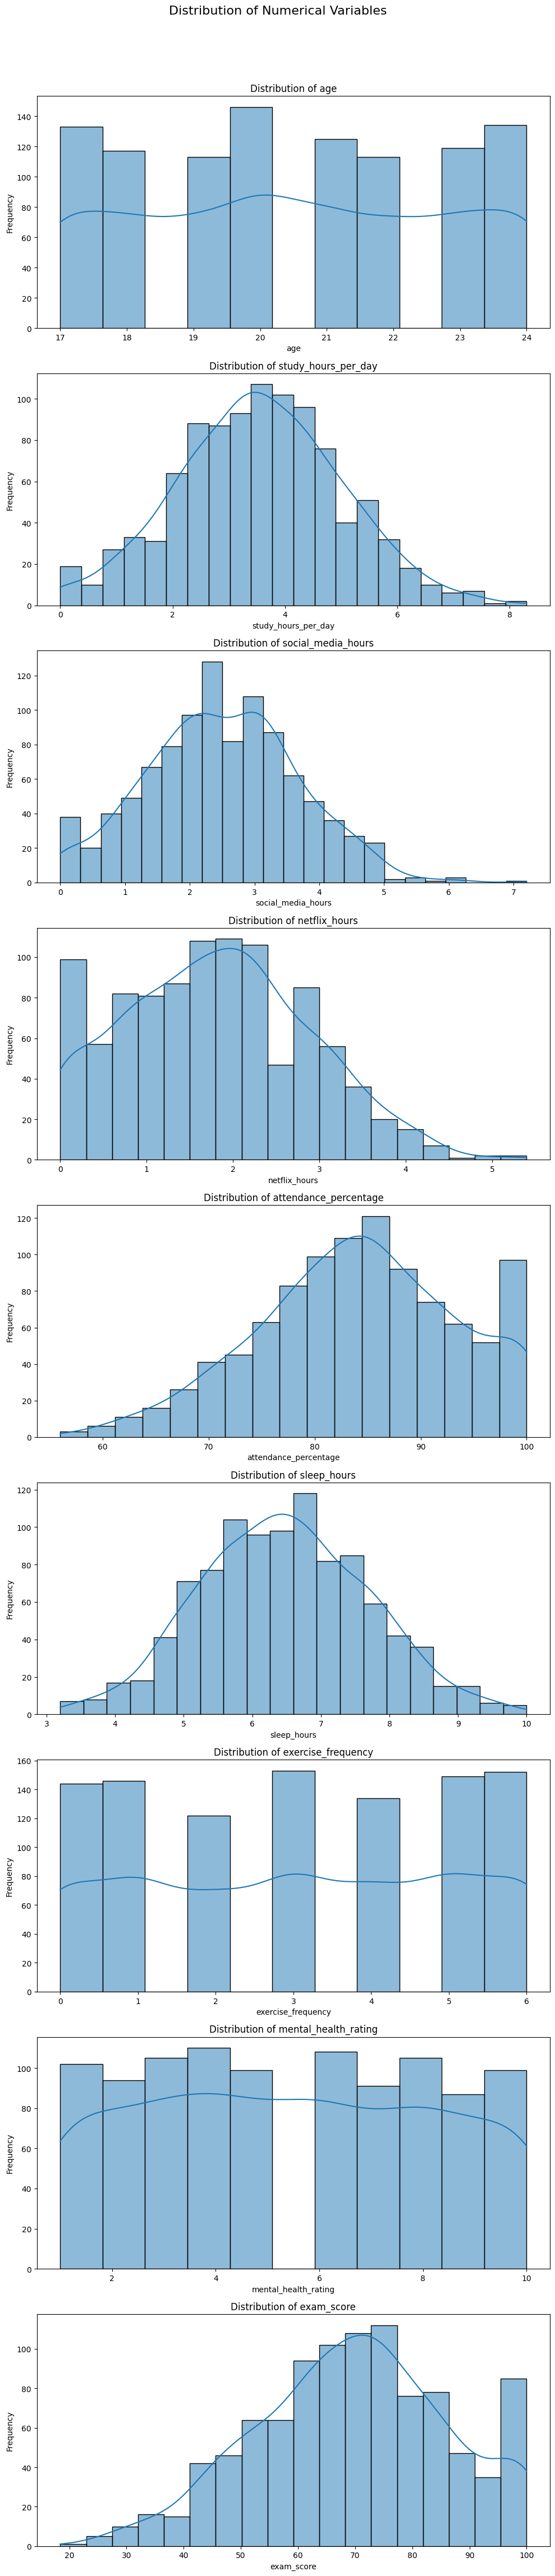

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms for numerical variables
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(10, 5 * len(numerical_cols)))
fig.suptitle('Distribution of Numerical Variables', y=1.02, fontsize=16)

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 1.3 Univariate Analysis of Categorical Variables

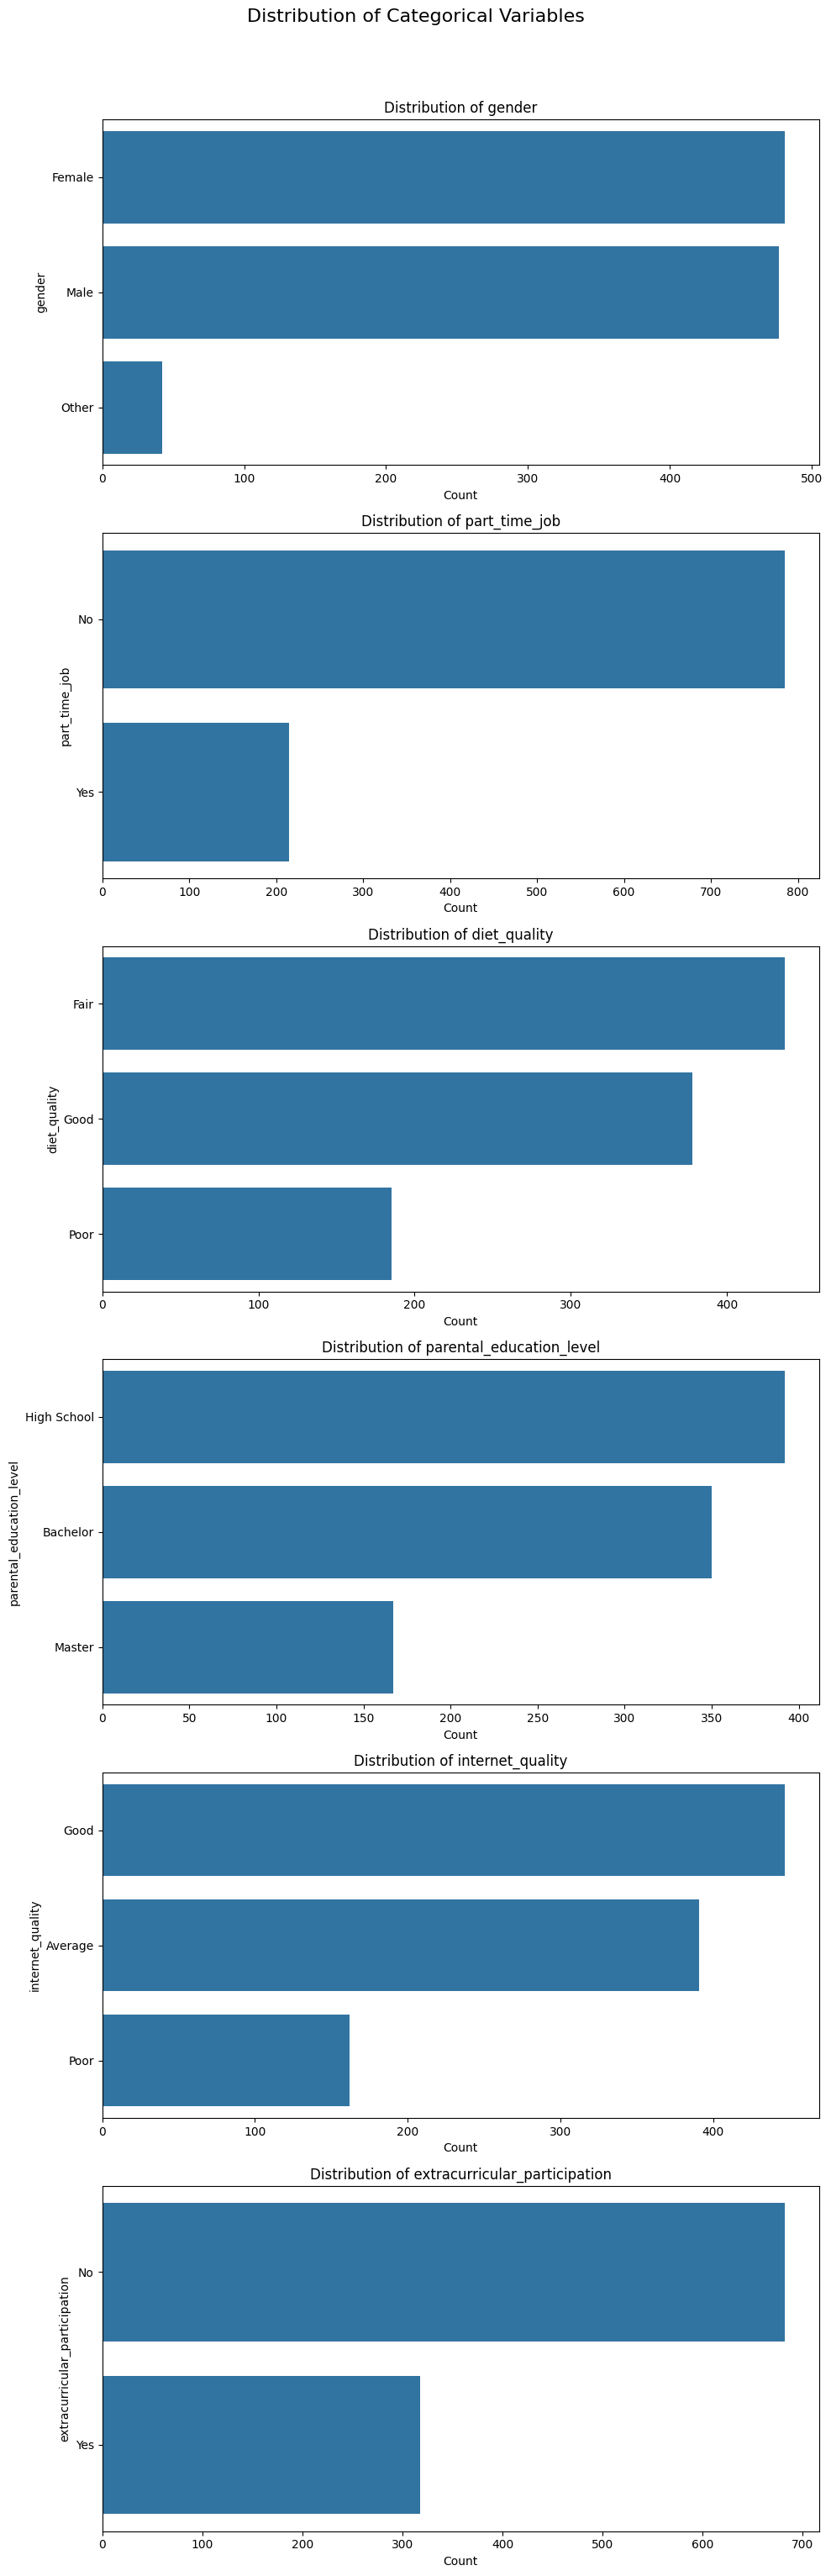

In [6]:
# Plot count plots for categorical variables
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(10, 5 * len(categorical_cols)))
fig.suptitle('Distribution of Categorical Variables', y=1.02, fontsize=16)

for i, col in enumerate(categorical_cols):
    sns.countplot(y=df[col], ax=axes[i], order = df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### 1.4 Bivariate Analysis: Numerical Variables vs. `exam_score`

Correlation Matrix:


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000000,0.003971,-0.009151,-0.001174,-0.026055,0.037482,-0.003836,-0.045101,-0.008907
study_hours_per_day,0.003971,1.000000,0.020282,-0.031158,0.026264,-0.027757,-0.028701,-0.003768,0.825419
social_media_hours,-0.009151,0.020282,1.000000,0.011477,0.040479,0.018236,-0.037319,0.001496,-0.166733
netflix_hours,-0.001174,-0.031158,0.011477,1.000000,-0.002092,-0.000935,-0.006448,0.008034,-0.171779
attendance_percentage,-0.026055,0.026264,0.040479,-0.002092,1.000000,0.013756,-0.007857,-0.018745,0.089836
sleep_hours,0.037482,-0.027757,0.018236,-0.000935,0.013756,1.000000,0.019769,-0.006508,0.121683
exercise_frequency,-0.003836,-0.028701,-0.037319,-0.006448,-0.007857,0.019769,1.000000,-0.000242,0.160107
mental_health_rating,-0.045101,-0.003768,0.001496,0.008034,-0.018745,-0.006508,-0.000242,1.000000,0.321523
exam_score,-0.008907,0.825419,-0.166733,-0.171779,0.089836,0.121683,0.160107,0.321523,1.000000



Correlation with exam_score:
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


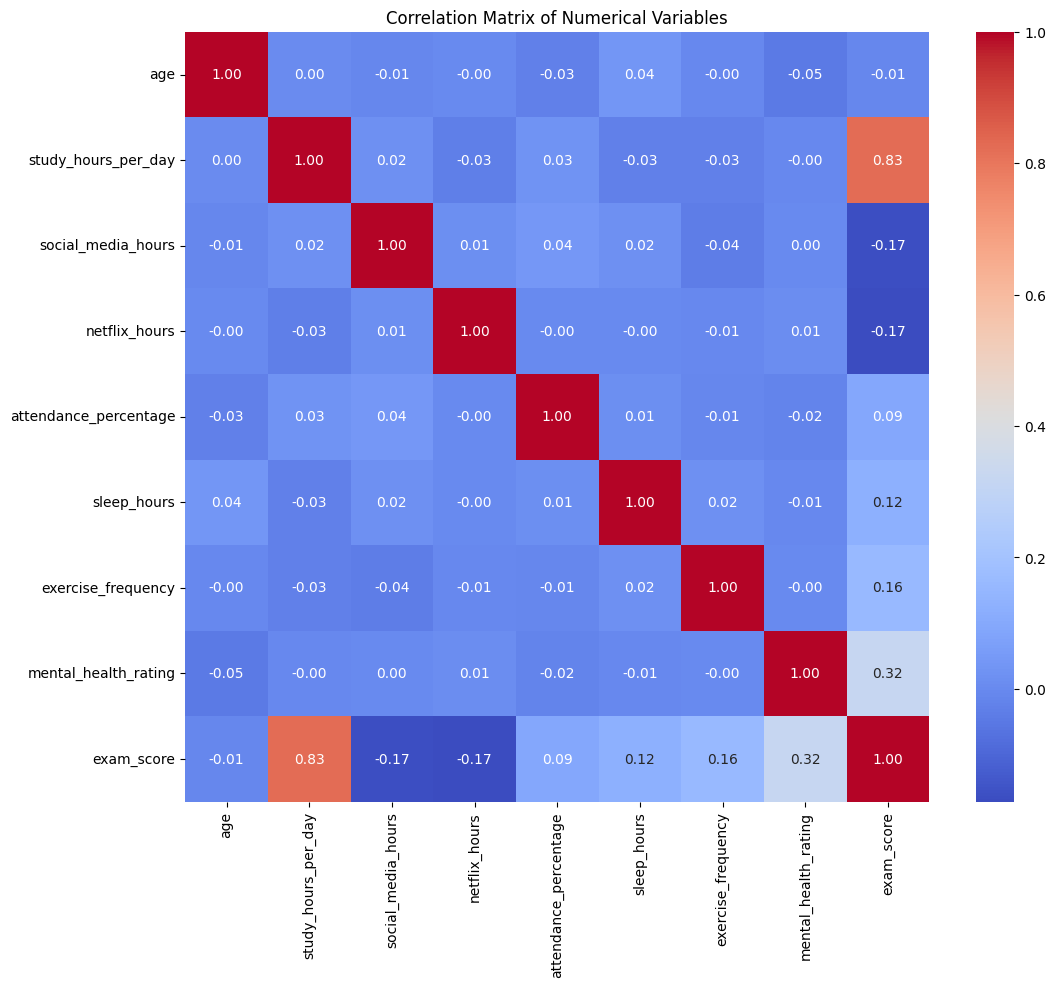

In [7]:
# Correlation matrix for numerical variables
correlation_matrix = df[numerical_cols].corr()
print('Correlation Matrix:')
display(correlation_matrix)

# Correlation with exam_score
print('\nCorrelation with exam_score:')
print(correlation_matrix['exam_score'].sort_values(ascending=False))

# Plotting heatmap of correlations
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### 1.5 Bivariate Analysis: Categorical Variables vs. `exam_score`

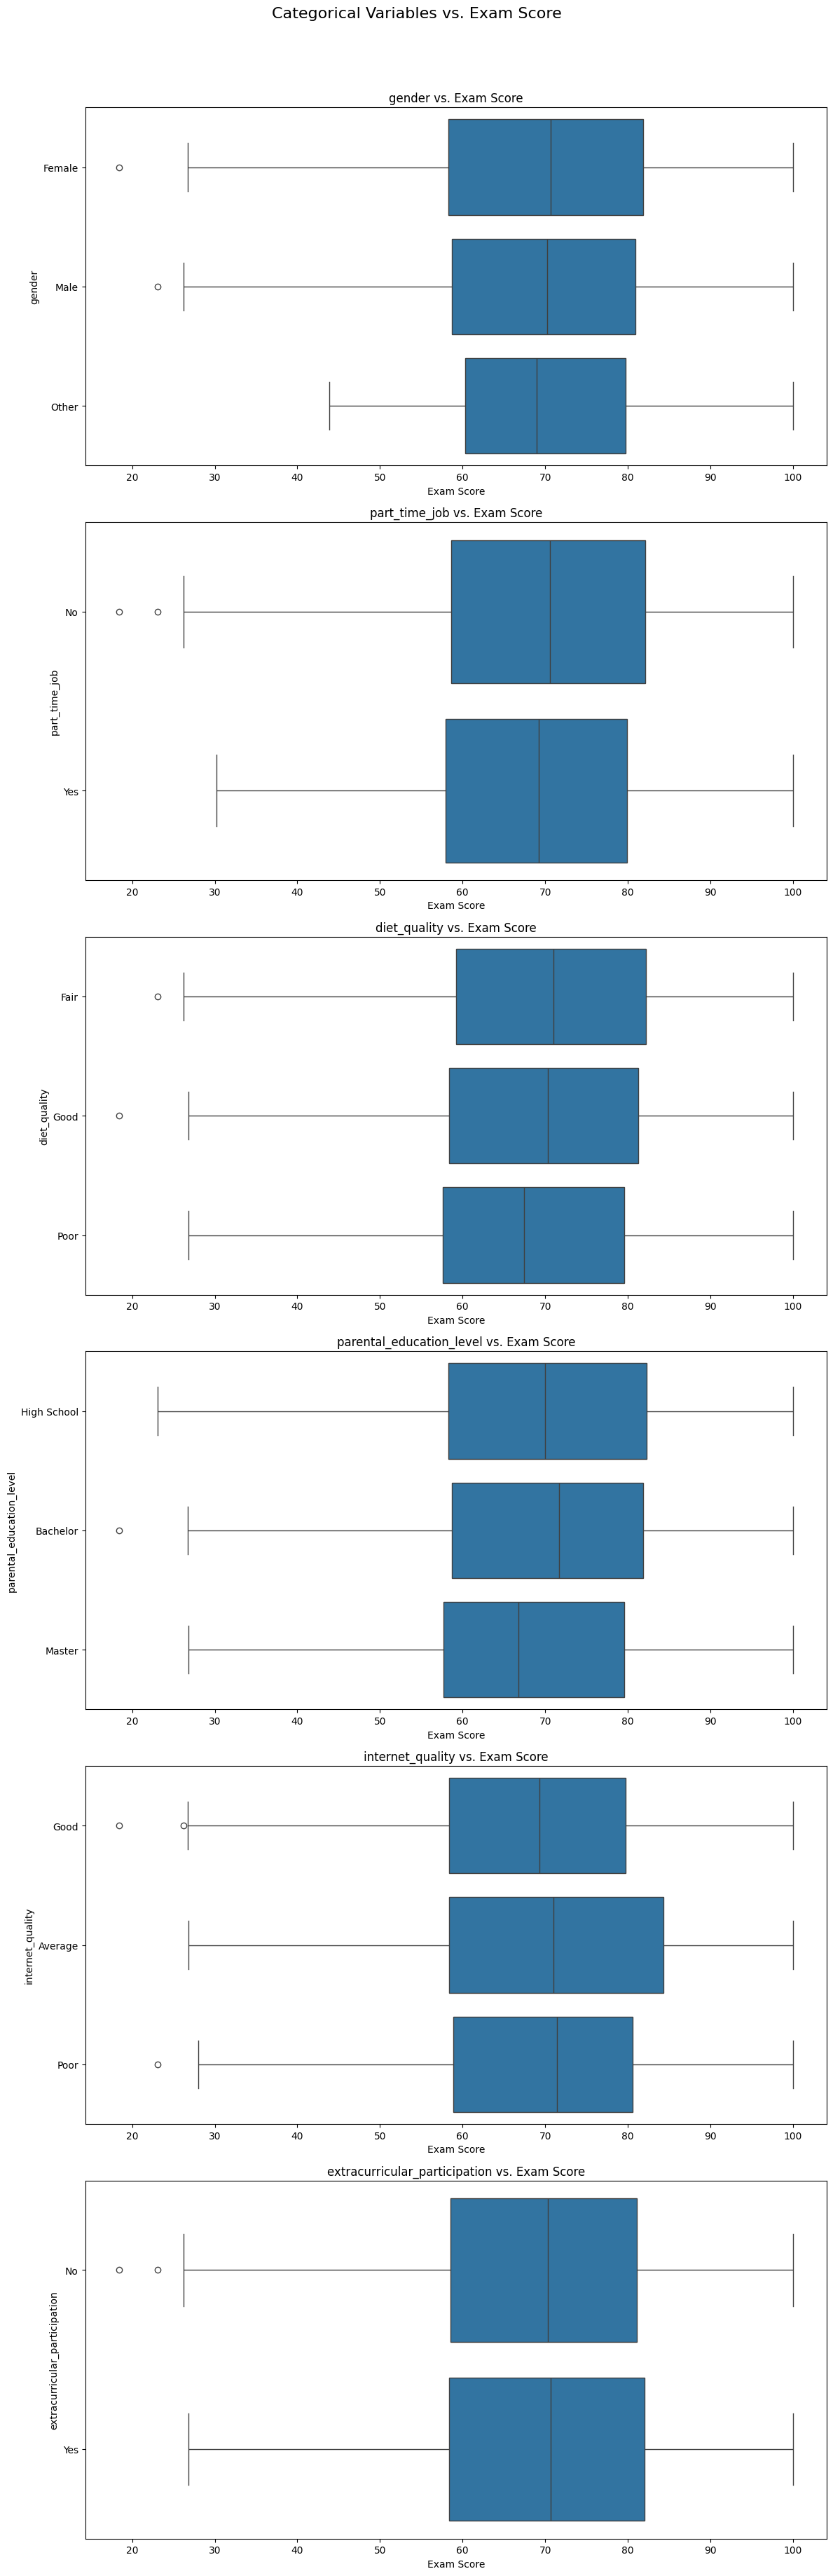

In [8]:
# Box plots for categorical variables vs. exam_score
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 6 * len(categorical_cols)))
fig.suptitle('Categorical Variables vs. Exam Score', y=1.02, fontsize=16)

for i, col in enumerate(categorical_cols):
    sns.boxplot(x='exam_score', y=col, data=df, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'{col} vs. Exam Score')
    axes[i].set_xlabel('Exam Score')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## 2. Data Preparation and Preprocessing

### 2.1 Handling Missing Values

In [9]:
# Handle missing values in 'parental_education_level' by imputation (e.g., mode)
mode_parental_education = df['parental_education_level'].mode()[0]
df.loc[:, 'parental_education_level'] = df['parental_education_level'].fillna(mode_parental_education)

print(f"Missing values after imputation:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Missing values after imputation:
Series([], dtype: int64)


### 2.2 Key EDA Findings and Feature Selection Insights

Based on the univariate and bivariate analysis:

*   **Missing Values**: Only `parental_education_level` had missing values, which have been imputed with the mode.
*   **Numerical Variable Correlations with `exam_score`**:
    *   `study_hours_per_day`: Shows a very strong positive correlation (0.825). This is the most significant positive predictor.
    *   `mental_health_rating`: Has a moderate positive correlation (0.321).
    *   `exercise_frequency`: Shows a weak positive correlation (0.160).
    *   `sleep_hours`: Has a weak positive correlation (0.121).
    *   `attendance_percentage`: Shows a weak positive correlation (0.089).
    *   `social_media_hours`: Shows a weak negative correlation (-0.166).
    *   `netflix_hours`: Shows a weak negative correlation (-0.171).
    *   `age`: Has a very negligible correlation.
*   **Categorical Variable Relationships with `exam_score`** (from box plots):
    *   `gender`: Differences in median exam scores appear minor across genders.
    *   `part_time_job`: Students with no part-time job might have slightly higher average scores.
    *   `diet_quality`: Could show some differences, with better diet quality possibly relating to higher scores.
    *   `parental_education_level`: There might be a trend where higher parental education levels correlate with higher student exam scores.
    *   `internet_quality`: Better internet quality might be associated with higher exam scores.
    *   `extracurricular_participation`: Participants might show different score distributions compared to non-participants.

**Selected Features for Regression Model**: Based on these insights, we will consider `study_hours_per_day`, `mental_health_rating`, `exercise_frequency`, `sleep_hours`, `attendance_percentage`, `social_media_hours`, `netflix_hours` as numerical features. All categorical features (`gender`, `part_time_job`, `diet_quality`, `parental_education_level`, `internet_quality`, `extracurricular_participation`) will also be included after one-hot encoding, as some show potential influence on `exam_score`.

### 2.3 Feature Engineering: One-Hot Encoding Categorical Variables

In [10]:
# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop student_id as it's just an identifier and not a feature
df_encoded = df_encoded.drop('student_id', axis=1)

print('DataFrame after one-hot encoding and dropping student_id:')
display(df_encoded.head())
print(f'Shape of the encoded DataFrame: {df_encoded.shape}')

DataFrame after one-hot encoding and dropping student_id:


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,False,False,False,False,False,False,True,False,False,True
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,False,False,False,True,False,True,False,False,False,False
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,True,False,False,False,True,True,False,False,True,False
3,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8,False,False,False,False,True,False,True,True,False,True
4,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4,False,False,False,False,False,False,True,True,False,False


Shape of the encoded DataFrame: (1000, 19)


### 2.4 Data Splitting for Regression Model

In [11]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('exam_score', axis=1)
y = df_encoded['exam_score']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (800, 18)
Shape of X_test: (200, 18)
Shape of y_train: (800,)
Shape of y_test: (200,)


## 3. Regression Problem: Predicting `exam_score`

### 3.1 Model Training: Linear Regression

In [12]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print('Linear Regression model trained successfully.')

Linear Regression model trained successfully.


### 3.2 Model Evaluation

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the training and testing sets
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

# Evaluate the model on the training set
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print('--- Training Set Evaluation ---')
print(f'Mean Absolute Error (MAE): {mae_train:.2f}')
print(f'Mean Squared Error (MSE): {mse_train:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_train:.2f}')
print(f'R-squared (R2): {r2_train:.2f}')

# Evaluate the model on the testing set
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print('\n--- Testing Set Evaluation ---')
print(f'Mean Absolute Error (MAE): {mae_test:.2f}')
print(f'Mean Squared Error (MSE): {mse_test:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_test:.2f}')
print(f'R-squared (R2): {r2_test:.2f}')

--- Training Set Evaluation ---
Mean Absolute Error (MAE): 4.21
Mean Squared Error (MSE): 28.57
Root Mean Squared Error (RMSE): 5.34
R-squared (R2): 0.90

--- Testing Set Evaluation ---
Mean Absolute Error (MAE): 4.19
Mean Squared Error (MSE): 26.53
Root Mean Squared Error (RMSE): 5.15
R-squared (R2): 0.90


## 4. Classification Problem: Predicting `Pass/Fail`

### 4.1 Data Preparation for Classification

In [14]:
# Create a 'Pass/Fail' target variable (1 for Pass, 0 for Fail)
# Passing threshold is 50 marks
df_encoded['pass_fail'] = (df_encoded['exam_score'] >= 50).astype(int)

# Define features (X_clf) and target (y_clf) for classification
X_clf = df_encoded.drop(['exam_score', 'pass_fail'], axis=1)
y_clf = df_encoded['pass_fail']

# Split the data into training and testing sets (80% train, 20% test)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f'Original target value counts:\n{df_encoded['pass_fail'].value_counts()}')
print(f'Shape of X_train_clf: {X_train_clf.shape}')
print(f'Shape of X_test_clf: {X_test_clf.shape}')
print(f'Shape of y_train_clf: {y_train_clf.shape}')
print(f'Shape of y_test_clf: {y_test_clf.shape}')

Original target value counts:
pass_fail
1    869
0    131
Name: count, dtype: int64
Shape of X_train_clf: (800, 18)
Shape of X_test_clf: (200, 18)
Shape of y_train_clf: (800,)
Shape of y_test_clf: (200,)


### 4.2 Model Training: Logistic Regression (Classification)

In [15]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
logistic_model.fit(X_train_clf, y_train_clf)

print('Logistic Regression model trained successfully.')

Logistic Regression model trained successfully.


### 4.3 Model Evaluation for Classification

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the training and testing sets
y_train_pred_clf = logistic_model.predict(X_train_clf)
y_test_pred_clf = logistic_model.predict(X_test_clf)

# Evaluate on training set
accuracy_train_clf = accuracy_score(y_train_clf, y_train_pred_clf)
precision_train_clf = precision_score(y_train_clf, y_train_pred_clf)
recall_train_clf = recall_score(y_train_clf, y_train_pred_clf)
f1_train_clf = f1_score(y_train_clf, y_train_pred_clf)
conf_matrix_train_clf = confusion_matrix(y_train_clf, y_train_pred_clf)

print('--- Training Set Classification Evaluation ---')
print(f'Accuracy: {accuracy_train_clf:.2f}')
print(f'Precision: {precision_train_clf:.2f}')
print(f'Recall: {recall_train_clf:.2f}')
print(f'F1-Score: {f1_train_clf:.2f}')
print('Confusion Matrix:\n', conf_matrix_train_clf)

# Evaluate on testing set
accuracy_test_clf = accuracy_score(y_test_clf, y_test_pred_clf)
precision_test_clf = precision_score(y_test_clf, y_test_pred_clf)
recall_test_clf = recall_score(y_test_clf, y_test_pred_clf)
f1_test_clf = f1_score(y_test_clf, y_test_pred_clf)
conf_matrix_test_clf = confusion_matrix(y_test_clf, y_test_pred_clf)

print('\n--- Testing Set Classification Evaluation ---')
print(f'Accuracy: {accuracy_test_clf:.2f}')
print(f'Precision: {precision_test_clf:.2f}')
print(f'Recall: {recall_test_clf:.2f}')
print(f'F1-Score: {f1_test_clf:.2f}')
print('Confusion Matrix:\n', conf_matrix_test_clf)

--- Training Set Classification Evaluation ---
Accuracy: 0.95
Precision: 0.96
Recall: 0.98
F1-Score: 0.97
Confusion Matrix:
 [[ 78  27]
 [ 13 682]]

--- Testing Set Classification Evaluation ---
Accuracy: 0.93
Precision: 0.95
Recall: 0.97
F1-Score: 0.96
Confusion Matrix:
 [[ 18   8]
 [  6 168]]


## 5. Model Comparison and Insights

### 5.1 Model Performance Summary

#### Regression Model (Linear Regression) for `exam_score`:
*   **Training Set**: MAE: 4.21, MSE: 28.57, RMSE: 5.34, R2: 0.90
*   **Testing Set**: MAE: 4.19, MSE: 26.53, RMSE: 5.15, R2: 0.90

#### Classification Model (Logistic Regression) for `Pass/Fail`:
*   **Training Set**: Accuracy: 0.95, Precision: 0.96, Recall: 0.98, F1-Score: 0.97
*   **Testing Set**: Accuracy: 0.93, Precision: 0.95, Recall: 0.97, F1-Score: 0.96

### 5.2 Overfitting/Underfitting Discussion

Both the Linear Regression and Logistic Regression models show very consistent performance between their training and testing sets. This indicates that **neither model is significantly overfitting or underfitting** the data. The models generalize well to unseen data, which is a desirable characteristic. The R-squared values for the regression model are very close (0.90 for both train and test), and the classification metrics (Accuracy, Precision, Recall, F1-Score) are also very similar for both train and test sets, suggesting good generalization.

### 5.3 Most Important Findings from EDA and Model Results

Based on our EDA and model results, here are some key findings:

1.  **`study_hours_per_day` is the dominant predictor for `exam_score`**: The EDA showed a very strong positive correlation (0.825) between `study_hours_per_day` and `exam_score`. This suggests that the amount of time a student spends studying is by far the most influential factor in their exam performance. Our regression model implicitly leverages this strong relationship.
2.  **Mental Health Impacts Performance**: `mental_health_rating` showed a moderate positive correlation (0.321) with `exam_score`, indicating that better mental health is associated with higher scores.
3.  **Screen Time Negatively Affects Performance**: `social_media_hours` (-0.166) and `netflix_hours` (-0.171) showed weak negative correlations with `exam_score`. While not as strong as study hours, excessive screen time appears to be a detrimental factor.
4.  **Parental Education and Internet Quality Matter**: The bivariate analysis with categorical variables suggested that `parental_education_level` and `internet_quality` likely influence `exam_score`. Students with higher parental education levels and better internet quality tended to have higher exam scores. This highlights socioeconomic and environmental factors.
5.  **Diet and Part-Time Jobs**: `diet_quality` and `part_time_job` also appeared to have some impact on `exam_score` distributions, suggesting that students with better diet quality and those without part-time jobs might perform better.
6.  **High Predictability of Pass/Fail**: The Logistic Regression model achieved high accuracy (0.93-0.95) in predicting whether a student would pass or fail, indicating that the features derived from student habits and demographics are very effective in classifying performance outcomes.

### 5.4 Conclusion: 5 Meaningful Insights

Here are 5 meaningful insights derived from the comprehensive analysis:

1.  **Prioritize Study Time**: The most critical factor for improving student exam scores is consistent study. Educational programs should strongly emphasize and facilitate dedicated study time.
2.  **Holistic Well-being is Key**: Beyond academics, factors like mental health, sleep, and exercise (though weaker) contribute to academic success. Supporting student well-being through counseling services, health education, and encouraging healthy habits could yield positive academic outcomes.
3.  **Moderate Screen Usage**: Excessive use of social media and Netflix is negatively associated with exam scores. Interventions encouraging balanced screen time could be beneficial.
4.  **Address Socio-Economic Disparities**: Parental education level and internet quality are influential, suggesting that socio-economic factors play a role in student performance. Providing support for students from less privileged backgrounds (e.g., access to better internet, academic resources) could help bridge performance gaps.
5.  **Passing is Highly Predictable**: The models effectively predict both the actual exam score and the pass/fail outcome. This predictability can be used for early identification of students at risk of failing, allowing for timely interventions and personalized support.

## 5. Model Comparison and Insights

### 5.1 Model Performance Summary

#### Regression Model (Linear Regression) for `exam_score`:
*   **Training Set**: MAE: 4.21, MSE: 28.57, RMSE: 5.34, R2: 0.90
*   **Testing Set**: MAE: 4.19, MSE: 26.53, RMSE: 5.15, R2: 0.90

#### Classification Model (Logistic Regression) for `Pass/Fail`:
*   **Training Set**: Accuracy: 0.95, Precision: 0.96, Recall: 0.98, F1-Score: 0.97
*   **Testing Set**: Accuracy: 0.93, Precision: 0.95, Recall: 0.97, F1-Score: 0.96

### 5.2 Overfitting/Underfitting Discussion

Both the Linear Regression and Logistic Regression models show very consistent performance between their training and testing sets. This indicates that **neither model is significantly overfitting or underfitting** the data. The models generalize well to unseen data, which is a desirable characteristic. The R-squared values for the regression model are very close (0.90 for both train and test), and the classification metrics (Accuracy, Precision, Recall, F1-Score) are also very similar for both train and test sets, suggesting good generalization.

### 5.3 Most Important Findings from EDA and Model Results

Based on our EDA and model results, here are some key findings:

1.  **`study_hours_per_day` is the dominant predictor for `exam_score`**: The EDA showed a very strong positive correlation (0.825) between `study_hours_per_day` and `exam_score`. This suggests that the amount of time a student spends studying is by far the most influential factor in their exam performance. Our regression model implicitly leverages this strong relationship.
2.  **Mental Health Impacts Performance**: `mental_health_rating` showed a moderate positive correlation (0.321) with `exam_score`, indicating that better mental health is associated with higher scores.
3.  **Screen Time Negatively Affects Performance**: `social_media_hours` (-0.166) and `netflix_hours` (-0.171) showed weak negative correlations with `exam_score`. While not as strong as study hours, excessive screen time appears to be a detrimental factor.
4.  **Parental Education and Internet Quality Matter**: The bivariate analysis with categorical variables suggested that `parental_education_level` and `internet_quality` likely influence `exam_score`. Students with higher parental education levels and better internet quality tended to have higher exam scores. This highlights socioeconomic and environmental factors.
5.  **Diet and Part-Time Jobs**: `diet_quality` and `part_time_job` also appeared to have some impact on `exam_score` distributions, suggesting that students with better diet quality and those without part-time jobs might perform better.
6.  **High Predictability of Pass/Fail**: The Logistic Regression model achieved high accuracy (0.93-0.95) in predicting whether a student would pass or fail, indicating that the features derived from student habits and demographics are very effective in classifying performance outcomes.

### 5.4 Conclusion: 5 Meaningful Insights

Here are 5 meaningful insights derived from the comprehensive analysis:

1.  **Prioritize Study Time**: The most critical factor for improving student exam scores is consistent study. Educational programs should strongly emphasize and facilitate dedicated study time.
2.  **Holistic Well-being is Key**: Beyond academics, factors like mental health, sleep, and exercise (though weaker) contribute to academic success. Supporting student well-being through counseling services, health education, and encouraging healthy habits could yield positive academic outcomes.
3.  **Moderate Screen Usage**: Excessive use of social media and Netflix is negatively associated with exam scores. Interventions encouraging balanced screen time could be beneficial.
4.  **Address Socio-Economic Disparities**: Parental education level and internet quality are influential, suggesting that socio-economic factors play a role in student performance. Providing support for students from less privileged backgrounds (e.g., access to better internet, academic resources) could help bridge performance gaps.
5.  **Passing is Highly Predictable**: The models effectively predict both the actual exam score and the pass/fail outcome. This predictability can be used for early identification of students at risk of failing, allowing for timely interventions and personalized support.

## 5. Model Comparison and Insights

### 5.1 Model Performance Summary

#### Regression Model (Linear Regression) for `exam_score`:
*   **Training Set**: MAE: 4.21, MSE: 28.57, RMSE: 5.34, R2: 0.90
*   **Testing Set**: MAE: 4.19, MSE: 26.53, RMSE: 5.15, R2: 0.90

#### Classification Model (Logistic Regression) for `Pass/Fail`:
*   **Training Set**: Accuracy: 0.95, Precision: 0.96, Recall: 0.98, F1-Score: 0.97
*   **Testing Set**: Accuracy: 0.93, Precision: 0.95, Recall: 0.97, F1-Score: 0.96

### 5.2 Overfitting/Underfitting Discussion

Both the Linear Regression and Logistic Regression models show very consistent performance between their training and testing sets. This indicates that **neither model is significantly overfitting or underfitting** the data. The models generalize well to unseen data, which is a desirable characteristic. The R-squared values for the regression model are very close (0.90 for both train and test), and the classification metrics (Accuracy, Precision, Recall, F1-Score) are also very similar for both train and test sets, suggesting good generalization.

### 5.3 Most Important Findings from EDA and Model Results

Based on our EDA and model results, here are some key findings:

1.  **`study_hours_per_day` is the dominant predictor for `exam_score`**: The EDA showed a very strong positive correlation (0.825) between `study_hours_per_day` and `exam_score`. This suggests that the amount of time a student spends studying is by far the most influential factor in their exam performance. Our regression model implicitly leverages this strong relationship.
2.  **Mental Health Impacts Performance**: `mental_health_rating` showed a moderate positive correlation (0.321) with `exam_score`, indicating that better mental health is associated with higher scores.
3.  **Screen Time Negatively Affects Performance**: `social_media_hours` (-0.166) and `netflix_hours` (-0.171) showed weak negative correlations with `exam_score`. While not as strong as study hours, excessive screen time appears to be a detrimental factor.
4.  **Parental Education and Internet Quality Matter**: The bivariate analysis with categorical variables suggested that `parental_education_level` and `internet_quality` likely influence `exam_score`. Students with higher parental education levels and better internet quality tended to have higher exam scores. This highlights socioeconomic and environmental factors.
5.  **Diet and Part-Time Jobs**: `diet_quality` and `part_time_job` also appeared to have some impact on `exam_score` distributions, suggesting that students with better diet quality and those without part-time jobs might perform better.
6.  **High Predictability of Pass/Fail**: The Logistic Regression model achieved high accuracy (0.93-0.95) in predicting whether a student would pass or fail, indicating that the features derived from student habits and demographics are very effective in classifying performance outcomes.

### 5.4 Conclusion: 5 Meaningful Insights

Here are 5 meaningful insights derived from the comprehensive analysis:

1.  **Prioritize Study Time**: The most critical factor for improving student exam scores is consistent study. Educational programs should strongly emphasize and facilitate dedicated study time.
2.  **Holistic Well-being is Key**: Beyond academics, factors like mental health, sleep, and exercise (though weaker) contribute to academic success. Supporting student well-being through counseling services, health education, and encouraging healthy habits could yield positive academic outcomes.
3.  **Moderate Screen Usage**: Excessive use of social media and Netflix is negatively associated with exam scores. Interventions encouraging balanced screen time could be beneficial.
4.  **Address Socio-Economic Disparities**: Parental education level and internet quality are influential, suggesting that socio-economic factors play a role in student performance. Providing support for students from less privileged backgrounds (e.g., access to better internet, academic resources) could help bridge performance gaps.
5.  **Passing is Highly Predictable**: The models effectively predict both the actual exam score and the pass/fail outcome. This predictability can be used for early identification of students at risk of failing, allowing for timely interventions and personalized support.

## 5. Model Comparison and Insights

### 5.1 Model Performance Summary

#### Regression Model (Linear Regression) for `exam_score`:
*   **Training Set**: MAE: 4.21, MSE: 28.57, RMSE: 5.34, R2: 0.90
*   **Testing Set**: MAE: 4.19, MSE: 26.53, RMSE: 5.15, R2: 0.90

#### Classification Model (Logistic Regression) for `Pass/Fail`:
*   **Training Set**: Accuracy: 0.95, Precision: 0.96, Recall: 0.98, F1-Score: 0.97
*   **Testing Set**: Accuracy: 0.93, Precision: 0.95, Recall: 0.97, F1-Score: 0.96

### 5.2 Overfitting/Underfitting Discussion

Both the Linear Regression and Logistic Regression models show very consistent performance between their training and testing sets. This indicates that **neither model is significantly overfitting or underfitting** the data. The models generalize well to unseen data, which is a desirable characteristic. The R-squared values for the regression model are very close (0.90 for both train and test), and the classification metrics (Accuracy, Precision, Recall, F1-Score) are also very similar for both train and test sets, suggesting good generalization.

### 5.3 Most Important Findings from EDA and Model Results

Based on our EDA and model results, here are some key findings:

1.  **`study_hours_per_day` is the dominant predictor for `exam_score`**: The EDA showed a very strong positive correlation (0.825) between `study_hours_per_day` and `exam_score`. This suggests that the amount of time a student spends studying is by far the most influential factor in their exam performance. Our regression model implicitly leverages this strong relationship.
2.  **Mental Health Impacts Performance**: `mental_health_rating` showed a moderate positive correlation (0.321) with `exam_score`, indicating that better mental health is associated with higher scores.
3.  **Screen Time Negatively Affects Performance**: `social_media_hours` (-0.166) and `netflix_hours` (-0.171) showed weak negative correlations with `exam_score`. While not as strong as study hours, excessive screen time appears to be a detrimental factor.
4.  **Parental Education and Internet Quality Matter**: The bivariate analysis with categorical variables suggested that `parental_education_level` and `internet_quality` likely influence `exam_score`. Students with higher parental education levels and better internet quality tended to have higher exam scores. This highlights socioeconomic and environmental factors.
5.  **Diet and Part-Time Jobs**: `diet_quality` and `part_time_job` also appeared to have some impact on `exam_score` distributions, suggesting that students with better diet quality and those without part-time jobs might perform better.
6.  **High Predictability of Pass/Fail**: The Logistic Regression model achieved high accuracy (0.93-0.95) in predicting whether a student would pass or fail, indicating that the features derived from student habits and demographics are very effective in classifying performance outcomes.

### 5.4 Conclusion: 5 Meaningful Insights

Here are 5 meaningful insights derived from the comprehensive analysis:

1.  **Prioritize Study Time**: The most critical factor for improving student exam scores is consistent study. Educational programs should strongly emphasize and facilitate dedicated study time.
2.  **Holistic Well-being is Key**: Beyond academics, factors like mental health, sleep, and exercise (though weaker) contribute to academic success. Supporting student well-being through counseling services, health education, and encouraging healthy habits could yield positive academic outcomes.
3.  **Moderate Screen Usage**: Excessive use of social media and Netflix is negatively associated with exam scores. Interventions encouraging balanced screen time could be beneficial.
4.  **Address Socio-Economic Disparities**: Parental education level and internet quality are influential, suggesting that socio-economic factors play a role in student performance. Providing support for students from less privileged backgrounds (e.g., access to better internet, academic resources) could help bridge performance gaps.
5.  **Passing is Highly Predictable**: The models effectively predict both the actual exam score and the pass/fail outcome. This predictability can be used for early identification of students at risk of failing, allowing for timely interventions and personalized support.

# Student Performance Prediction and Model Evaluation

This notebook implements a complete machine learning workflow to predict student performance and evaluate the model. The steps include:

1.  **Exploratory Data Analysis (EDA)**
2.  **Regression Problem: Predicting `exam_score`**
    *   Data Preparation
    *   Model Training (Linear Regression)
    *   Model Evaluation
3.  **Classification Problem: Predicting `Pass/Fail`**
    *   Data Preparation
    *   Model Training
    *   Model Evaluation
4.  **Model Comparison and Insights**

## 1. Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Day18_19_student_habits_performance.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

# Display basic information about the DataFrame
print('\nInformation about the dataset:')
df.info()

First 5 rows of the dataset:


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality 

### 1.1 Missing Values Analysis

In [2]:
# Check for missing values
print('Missing values in each column:')
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Exclude 'student_id' from numerical or categorical if it's just an identifier
if 'student_id' in numerical_cols:
    numerical_cols.remove('student_id')
if 'student_id' in categorical_cols:
    categorical_cols.remove('student_id')

print(f'\nNumerical columns: {numerical_cols}')
print(f'Categorical columns: {categorical_cols}')

Missing values in each column:
parental_education_level    91
dtype: int64

Numerical columns: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']
Categorical columns: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


### 1.2 Univariate Analysis of Numerical Variables

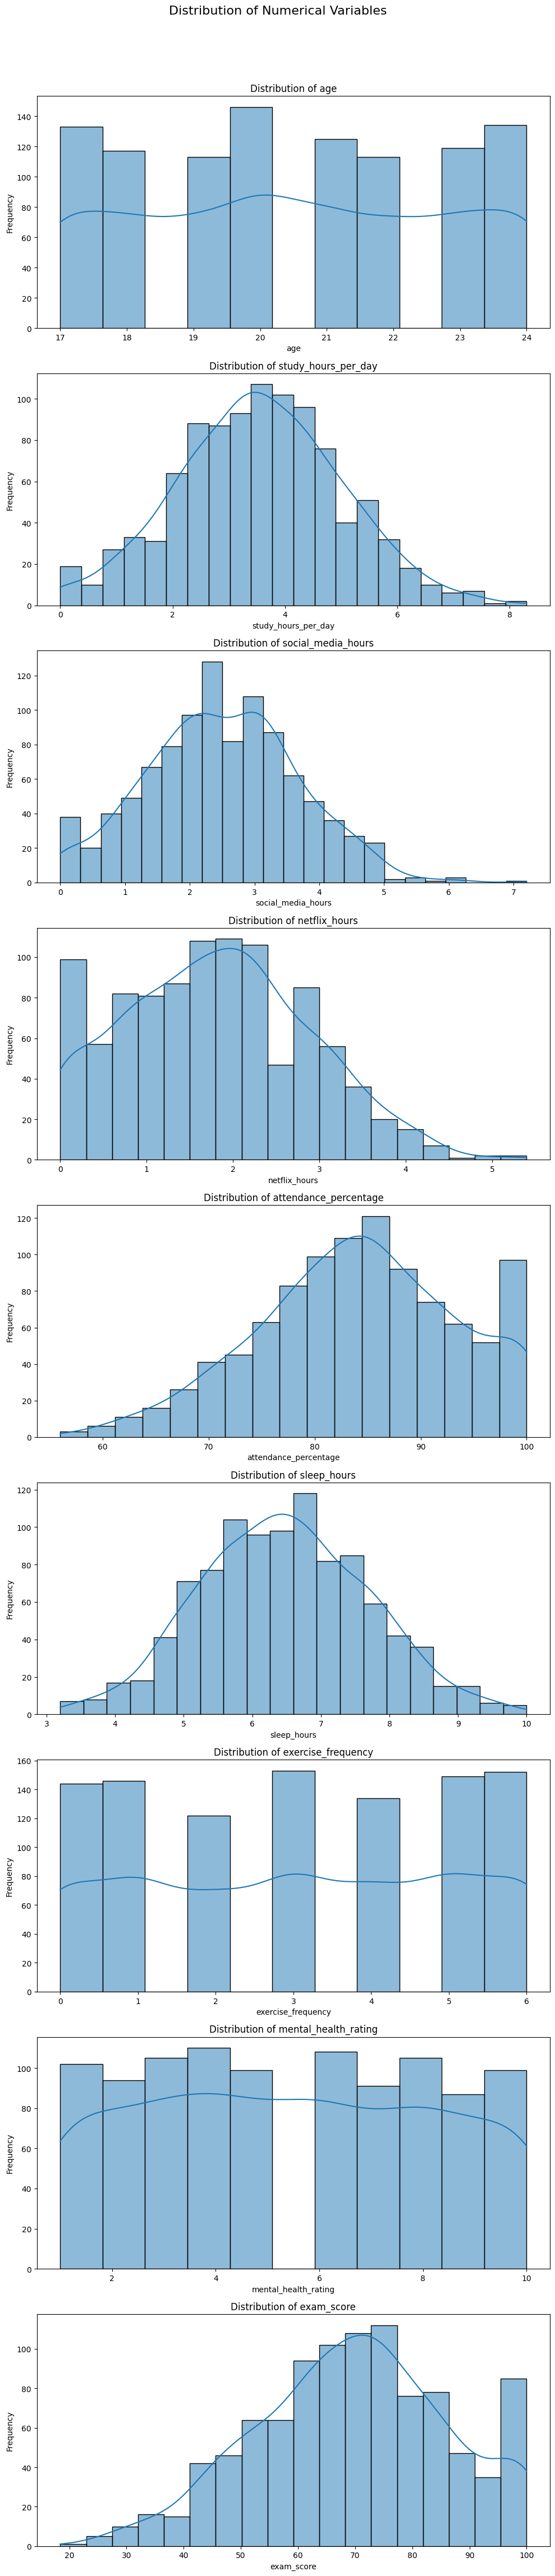

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms for numerical variables
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(10, 5 * len(numerical_cols)))
fig.suptitle('Distribution of Numerical Variables', y=1.02, fontsize=16)

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 1.3 Univariate Analysis of Categorical Variables

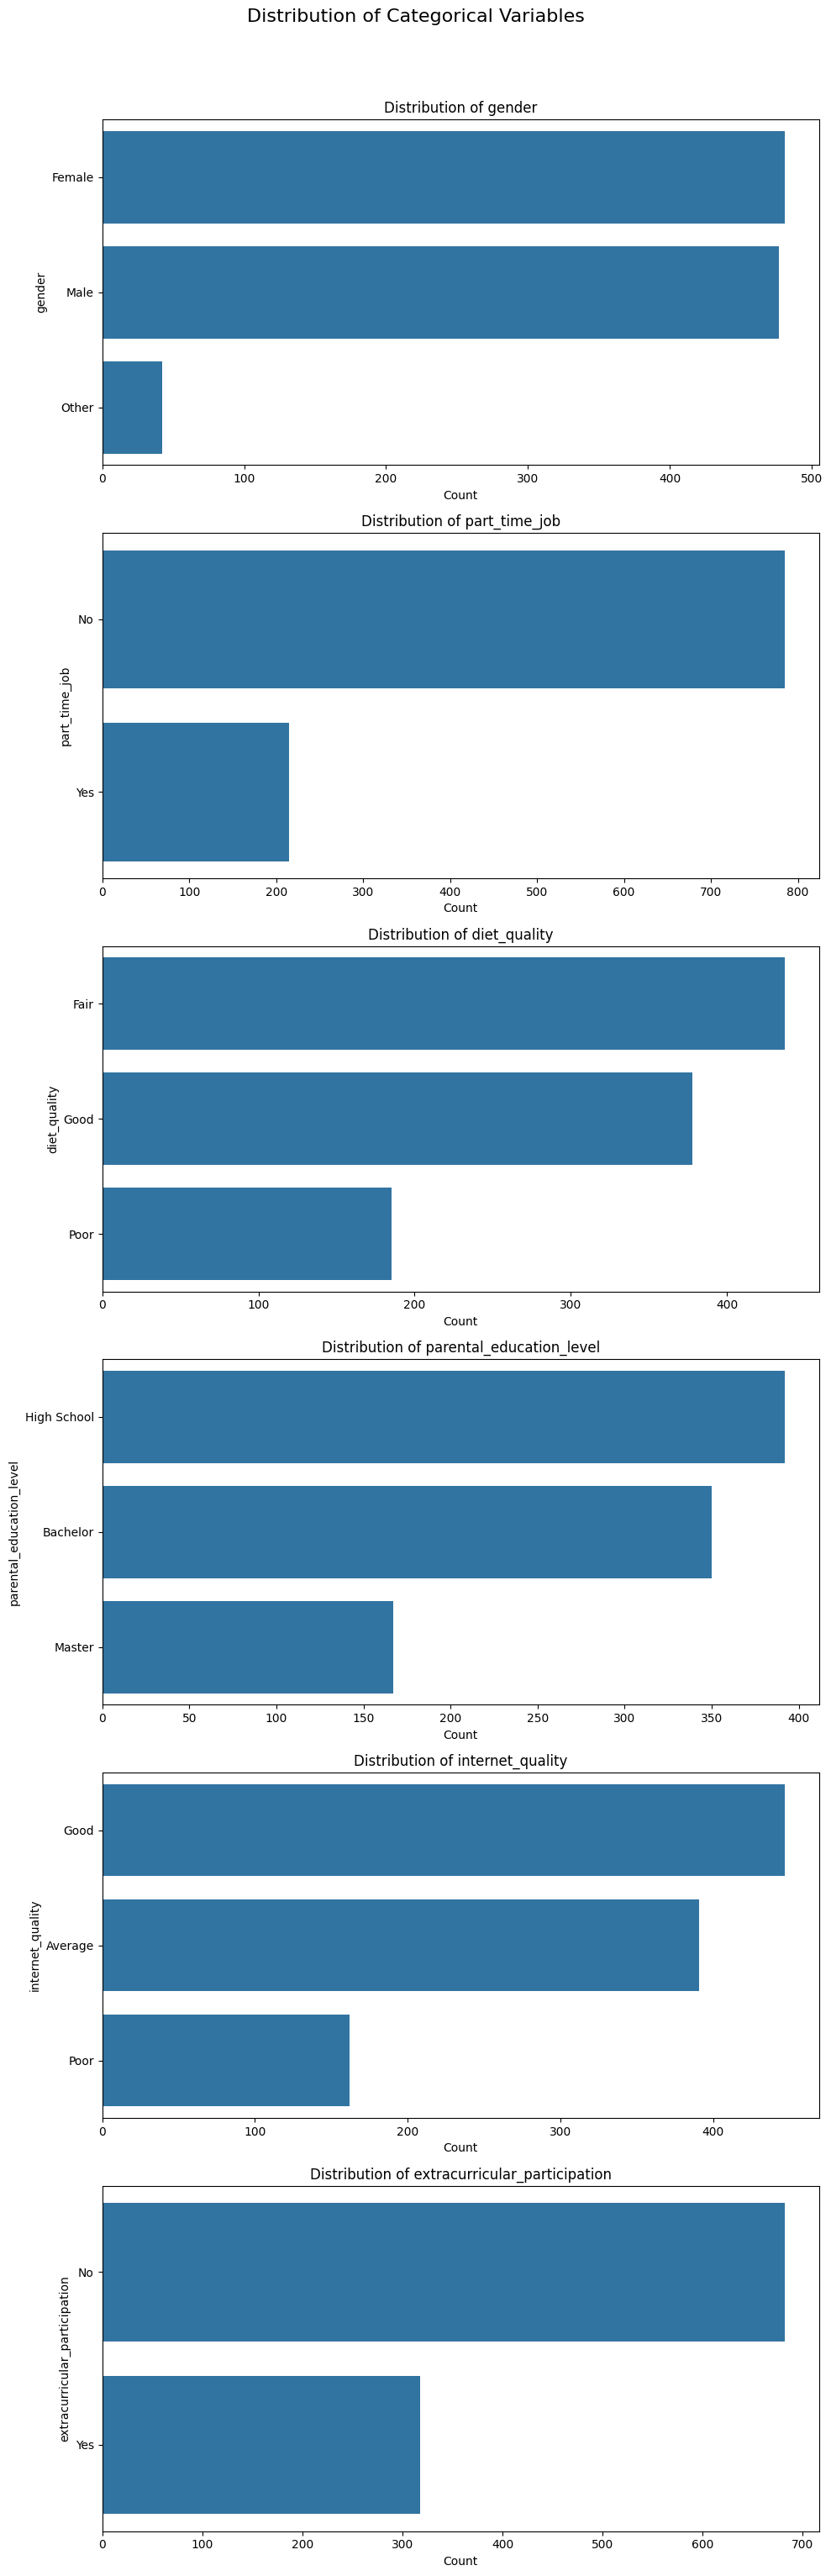

In [4]:
# Plot count plots for categorical variables
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(10, 5 * len(categorical_cols)))
fig.suptitle('Distribution of Categorical Variables', y=1.02, fontsize=16)

for i, col in enumerate(categorical_cols):
    sns.countplot(y=df[col], ax=axes[i], order = df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### 1.4 Bivariate Analysis: Numerical Variables vs. `exam_score`

Correlation Matrix:


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000000,0.003971,-0.009151,-0.001174,-0.026055,0.037482,-0.003836,-0.045101,-0.008907
study_hours_per_day,0.003971,1.000000,0.020282,-0.031158,0.026264,-0.027757,-0.028701,-0.003768,0.825419
social_media_hours,-0.009151,0.020282,1.000000,0.011477,0.040479,0.018236,-0.037319,0.001496,-0.166733
netflix_hours,-0.001174,-0.031158,0.011477,1.000000,-0.002092,-0.000935,-0.006448,0.008034,-0.171779
attendance_percentage,-0.026055,0.026264,0.040479,-0.002092,1.000000,0.013756,-0.007857,-0.018745,0.089836
sleep_hours,0.037482,-0.027757,0.018236,-0.000935,0.013756,1.000000,0.019769,-0.006508,0.121683
exercise_frequency,-0.003836,-0.028701,-0.037319,-0.006448,-0.007857,0.019769,1.000000,-0.000242,0.160107
mental_health_rating,-0.045101,-0.003768,0.001496,0.008034,-0.018745,-0.006508,-0.000242,1.000000,0.321523
exam_score,-0.008907,0.825419,-0.166733,-0.171779,0.089836,0.121683,0.160107,0.321523,1.000000



Correlation with exam_score:
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


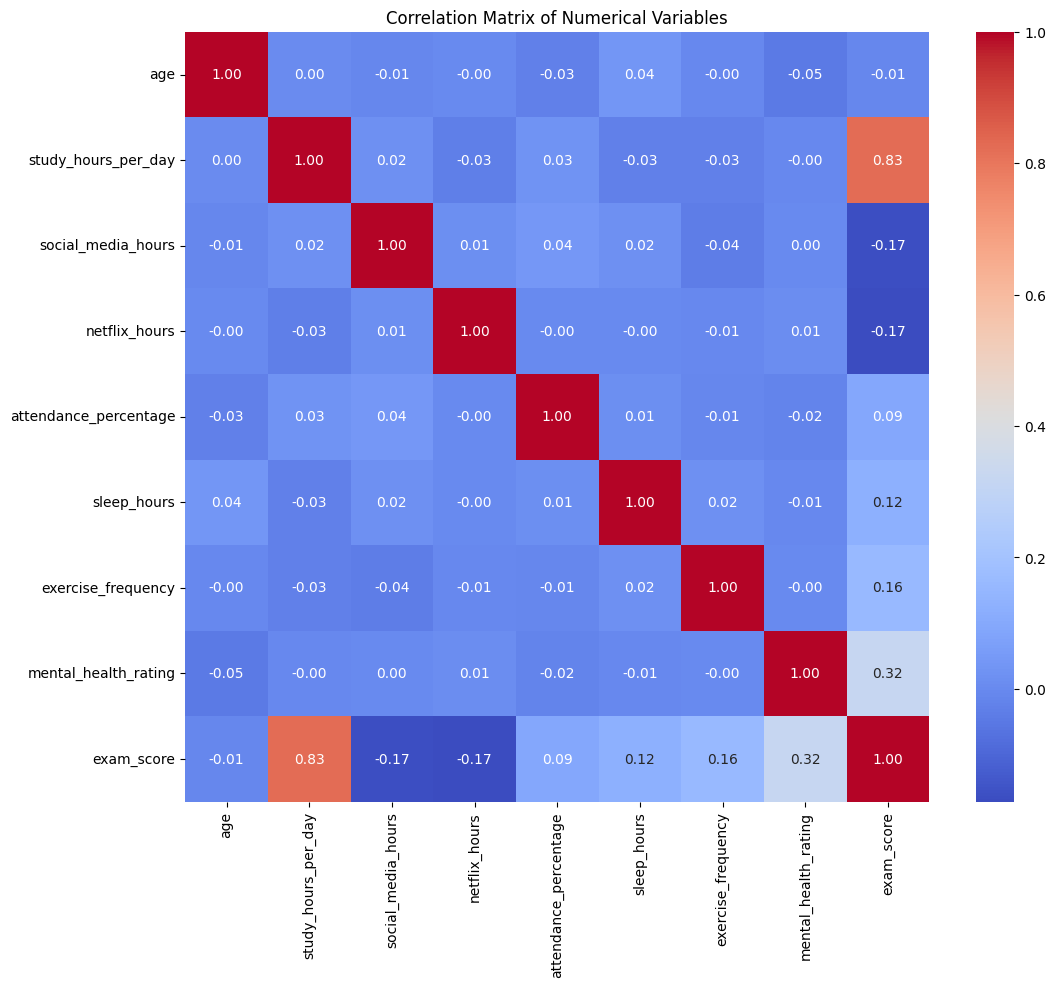

In [5]:
# Correlation matrix for numerical variables
correlation_matrix = df[numerical_cols].corr()
print('Correlation Matrix:')
display(correlation_matrix)

# Correlation with exam_score
print('\nCorrelation with exam_score:')
print(correlation_matrix['exam_score'].sort_values(ascending=False))

# Plotting heatmap of correlations
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### 1.5 Bivariate Analysis: Categorical Variables vs. `exam_score`

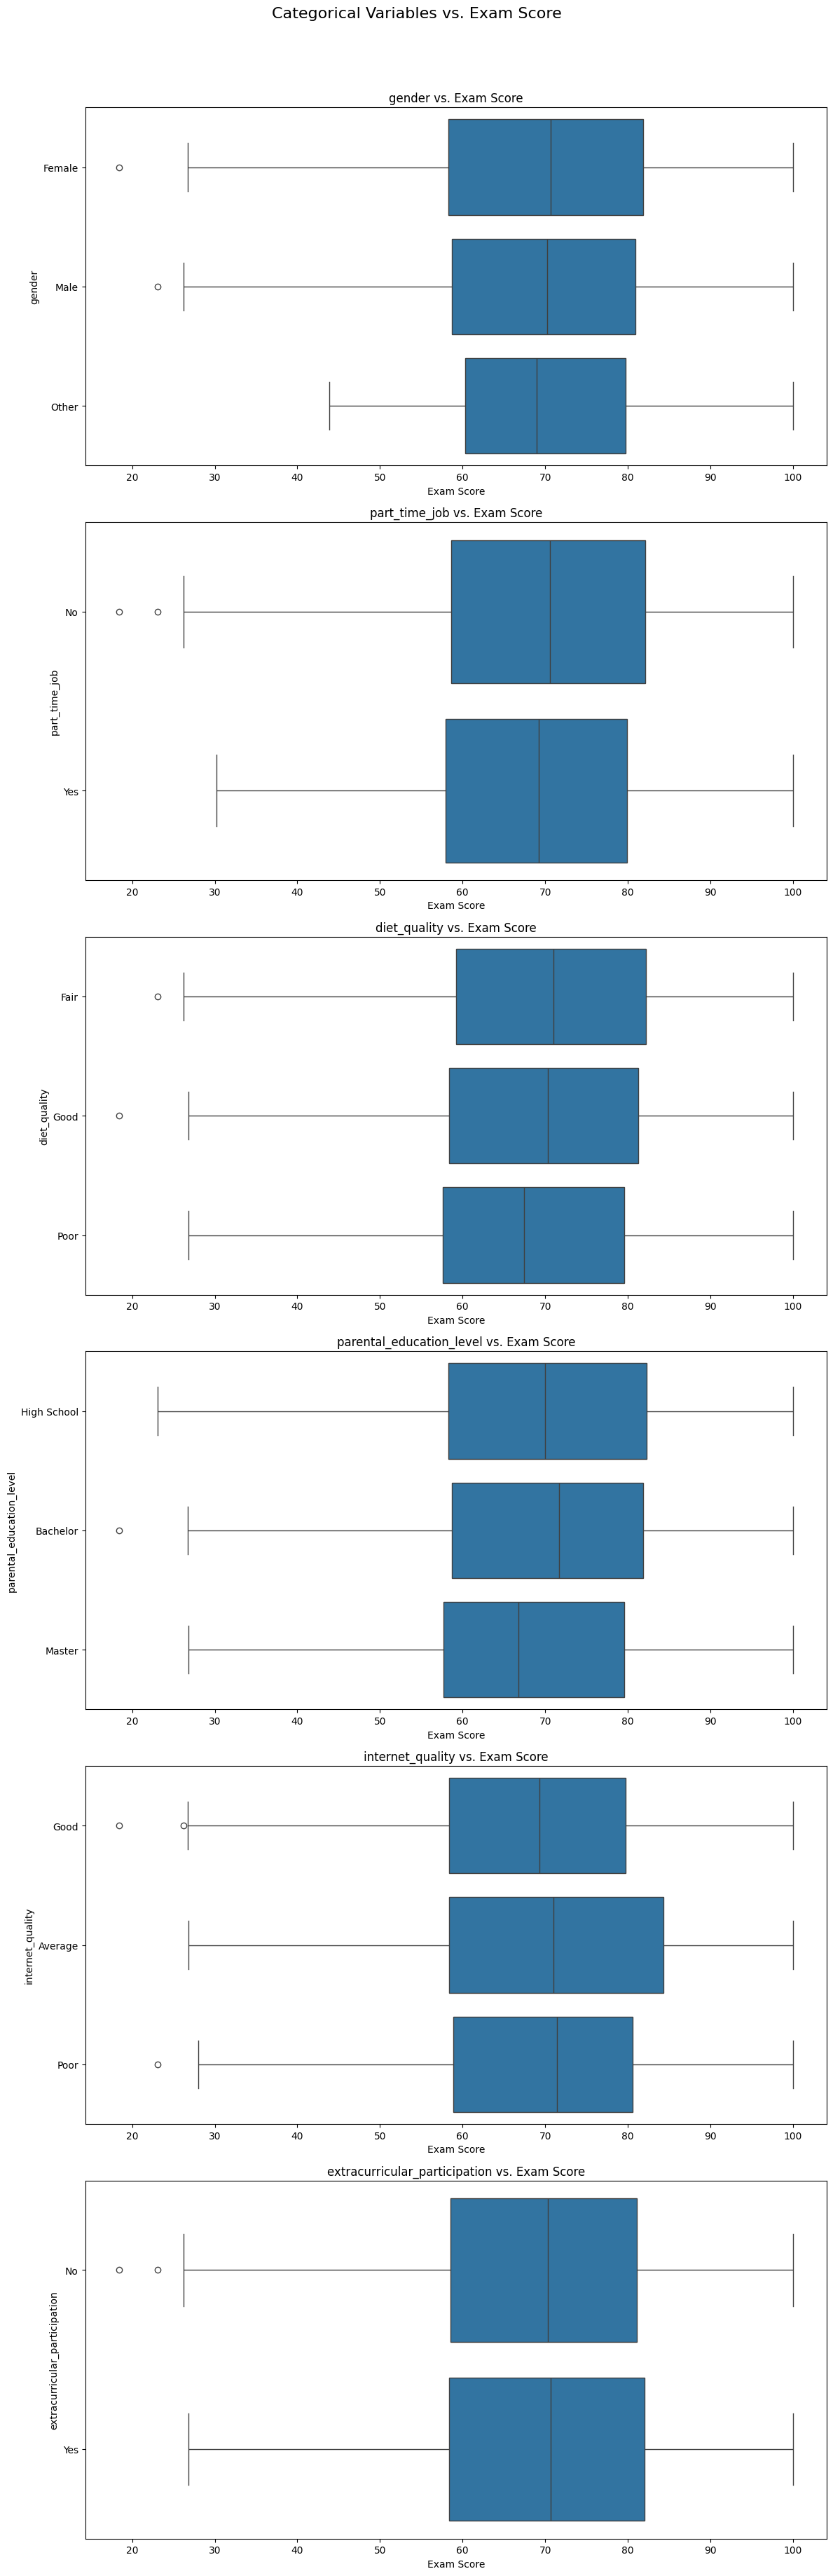

In [6]:
# Box plots for categorical variables vs. exam_score
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 6 * len(categorical_cols)))
fig.suptitle('Categorical Variables vs. Exam Score', y=1.02, fontsize=16)

for i, col in enumerate(categorical_cols):
    sns.boxplot(x='exam_score', y=col, data=df, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'{col} vs. Exam Score')
    axes[i].set_xlabel('Exam Score')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## 2. Data Preparation and Preprocessing

### 2.1 Handling Missing Values

In [2]:
import pandas as pd

# Reload the dataset if df is not defined (to handle potential kernel state loss)
if 'df' not in locals() and 'df' not in globals():
    df = pd.read_csv('/content/Day18_19_student_habits_performance.csv')

# Handle missing values in 'parental_education_level' by imputation (e.g., mode)
mode_parental_education = df['parental_education_level'].mode()[0]
df.loc[:, 'parental_education_level'] = df['parental_education_level'].fillna(mode_parental_education)

print(f"Missing values after imputation:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Day18_19_student_habits_performance.csv'